# ☕ Kahve Satış Analizi

## 1. Proje Hakkında

Bu projede bir kahve satış noktasının yaklaşık bir yıllık satış kayıtlarını inceledim. Amacım karmaşık modeller kurmak değil, veriye basit sorular sormaktı: En çok ne satılıyor? Hangi saatlerde? Sabah ve akşam aynı şeyler mi alınıyor? Hafta sonu daha mı sakin?

Veriyi Kaggle'daki [Coffee Sales](https://www.kaggle.com/datasets/ihelon/coffee-sales) veri setinden aldım. Veri setinin açıklamasına göre kayıtlar bir kahve otomatına ait. Ben setteki `index_1.csv` dosyasını kullandım; her satır tek bir satışı gösteriyor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Grafiklerde kullanacağım renkleri ve genel görünümü baştan ayarlıyorum. Her ürüne bir renk verdim, böylece aynı ürün bütün grafiklerde aynı renkte görünüyor.

In [2]:
# Her ürünün sabit bir rengi var
renkler = {
    "Americano with Milk": "#2a78d6",
    "Latte": "#eb6834",
    "Americano": "#1baf7a",
    "Cappuccino": "#4a3aa7",
    "Cortado": "#eda100",
    "Hot Chocolate": "#e34948",
    "Cocoa": "#e87ba4",
    "Espresso": "#008300",
}

# Ürün dışındaki grafikler için koyu ve açık gri
KOYU = "#3a3a37"
ACIK = "#cfcec9"
GRI_YAZI = "#6b6a66"

sns.set_theme(style="white")
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlelocation"] = "left"


# Sayıları Türkçe yazmak için: 22.66 -> "22,7"
def tr(sayi, basamak=1):
    return f"{sayi:.{basamak}f}".replace(".", ",")


# Başlık (soru) + altına kısa cevap
def baslik(ax, soru, cevap):
    ax.set_title(soru, pad=26)
    ax.text(0, 1.025, cevap, transform=ax.transAxes, fontsize=10.5, color=GRI_YAZI)


# Grafiği images klasörüne kaydet ve notebook'ta göster
def kaydet(fig, dosya_adi):
    fig.savefig(f"images/{dosya_adi}.png", bbox_inches="tight", facecolor="white", dpi=150)
    plt.show()

## 2. Veri Setini Tanıyalım

In [3]:
df = pd.read_csv("data/coffee_sales.csv")
print(df.shape)
df.head()

(3636, 6)


,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   str    
 1   datetime     3636 non-null   str    
 2   cash_type    3636 non-null   str    
 3   card         3547 non-null   str    
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   str    
dtypes: float64(1), str(5)
memory usage: 170.6 KB


In [5]:
print("Tarih aralığı:", df["date"].min(), "-", df["date"].max())
print("Fiyat aralığı:", df["money"].min(), "-", df["money"].max())
print("Farklı kart sayısı:", df["card"].nunique())
print()
print(df["coffee_name"].value_counts())
print()
print(df["cash_type"].value_counts())

Tarih aralığı: 2024-03-01 - 2025-03-23
Fiyat aralığı: 18.12 - 40.0
Farklı kart sayısı: 1316

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64

cash_type
card    3547
cash      89
Name: count, dtype: int64


Toplam 3.636 satış var, tarih aralığı 1 Mart 2024 - 23 Mart 2025. Veride 8 ürün ve 2 ödeme yöntemi (kart, nakit) bulunuyor. Fiyatlar 18,12 ile 40 arasında değişiyor. Para birimi belirtilmemiş, o yüzden tutarları birimsiz kullandım. `card` sütunu anonimleştirilmiş kart numaralarını tutuyor.

## 3. Veri Temizleme

In [6]:
print(df.isna().sum())
print("Tekrar eden satır:", df.duplicated().sum())

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64
Tekrar eden satır: 0


Sadece `card` sütununda 89 boş değer var. Bunların nakit ödemeler olup olmadığını kontrol ettim:

In [7]:
pd.crosstab(df["card"].isna(), df["cash_type"])

cash_type,card,cash
card,,
False,3547,0
True,0,89


Boş olanların hepsi nakit ödeme. Nakit ödemede kart numarası olmayacağı için bu bir hata değil. Satırları silmek yerine boşlukları "NAKIT" yazarak doldurdum. Tekrar eden satır yok.

In [8]:
df["card"] = df["card"].fillna("NAKIT")

# Tarihleri tarih formatına çeviriyorum
df["date"] = pd.to_datetime(df["date"])
df["datetime"] = pd.to_datetime(df["datetime"])

# Analizde kullanacağım yeni sütunlar
gunler = ["Pazartesi", "Salı", "Çarşamba", "Perşembe", "Cuma", "Cumartesi", "Pazar"]
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.dayofweek.map(lambda i: gunler[i])
df["is_weekend"] = df["datetime"].dt.dayofweek >= 5
df["year_month"] = df["datetime"].dt.to_period("M")

df.head()

,date,datetime,cash_type,card,money,coffee_name,hour,weekday,is_weekend,year_month
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,10,Cuma,False,2024-03
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12,Cuma,False,2024-03
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,12,Cuma,False,2024-03
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,13,Cuma,False,2024-03
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,13,Cuma,False,2024-03


Fiyatlarda mantıksız bir değer var mı diye ürün bazında da baktım:

In [9]:
df.groupby("coffee_name")["money"].agg(["min", "mean", "max"]).round(2)

,min,mean,max
coffee_name,,,
Americano,23.02,26.06,30.0
Americano with Milk,27.92,30.67,35.0
Cappuccino,32.82,36.00,40.0
Cocoa,32.82,35.71,40.0
Cortado,23.02,25.80,30.0
Espresso,18.12,21.00,25.0
Hot Chocolate,32.82,36.07,40.0
Latte,32.82,35.63,40.0


Her ürünün fiyatı kendi içinde makul bir aralıkta. Fiyatlar yıl içinde birkaç kez değişmiş, ama aykırı bir değer görmedim. Satışlar 06:00 ile 22:59 arasında yapılmış.

## 4. İnsanlar En Çok Hangi Kahveyi Alıyor?

In [10]:
urunler = df.groupby("coffee_name").agg(
    satis=("money", "count"),
    gelir=("money", "sum"),
    ort_fiyat=("money", "mean"),
)
urunler["satis_payi"] = urunler["satis"] / urunler["satis"].sum() * 100
urunler["gelir_payi"] = urunler["gelir"] / urunler["gelir"].sum() * 100
urunler = urunler.sort_values("satis", ascending=False)
urunler.round(1)

,satis,gelir,ort_fiyat,satis_payi,gelir_payi
coffee_name,,,,,
Americano with Milk,824,25269.1,30.7,22.7,21.9
Latte,782,27866.3,35.6,21.5,24.1
Americano,578,15062.3,26.1,15.9,13.0
Cappuccino,501,18034.1,36.0,13.8,15.6
Cortado,292,7534.9,25.8,8.0,6.5
Hot Chocolate,282,10172.5,36.1,7.8,8.8
Cocoa,243,8678.2,35.7,6.7,7.5
Espresso,134,2814.3,21.0,3.7,2.4


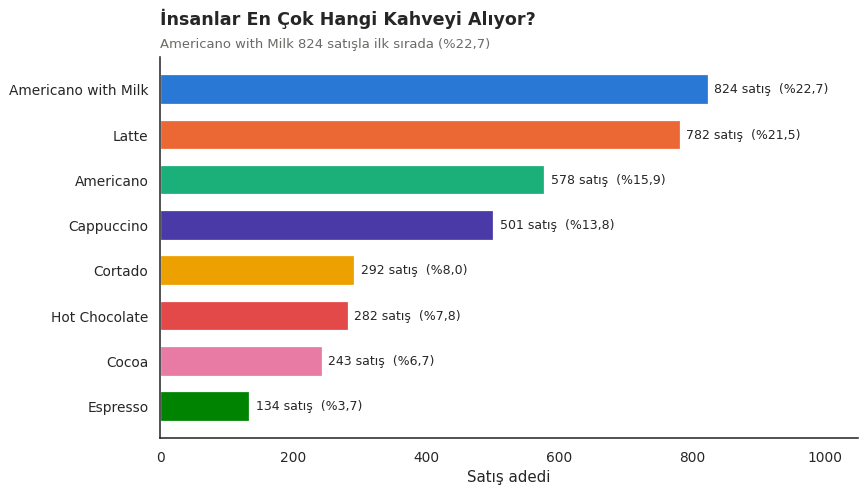

In [11]:
veri = urunler.sort_values("satis")   # en büyük en üstte görünsün diye

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(veri.index, veri["satis"], color=[renkler[u] for u in veri.index], height=0.65)

for i, (adet, pay) in enumerate(zip(veri["satis"], veri["satis_payi"])):
    ax.text(adet + 10, i, f"{adet} satış  (%{tr(pay)})", va="center", fontsize=10)

ax.set_xlim(0, 1050)
ax.set_xlabel("Satış adedi")
baslik(ax, "İnsanlar En Çok Hangi Kahveyi Alıyor?", "Americano with Milk 824 satışla ilk sırada (%22,7)")
kaydet(fig, "top_products")

**Bu bize ne söylüyor?**

En çok satan ürün 824 satışla Americano with Milk. Tüm satışların %22,7'si bu üründen geliyor; yani yaklaşık her 4-5 satıştan biri. Latte 782 satışla hemen arkasında. İlk dört ürün (Americano with Milk, Latte, Americano, Cappuccino) birlikte satışların %74'ünü oluşturuyor. En az satan ürün ise %3,7 ile Espresso.

## 5. En Çok Satan Kahve En Çok Gelir Getiren Kahve mi?

Burada her ürünün satış adedi payıyla gelir payını yan yana koydum. İki çizgi kesişiyorsa sıralama değişiyor demek.

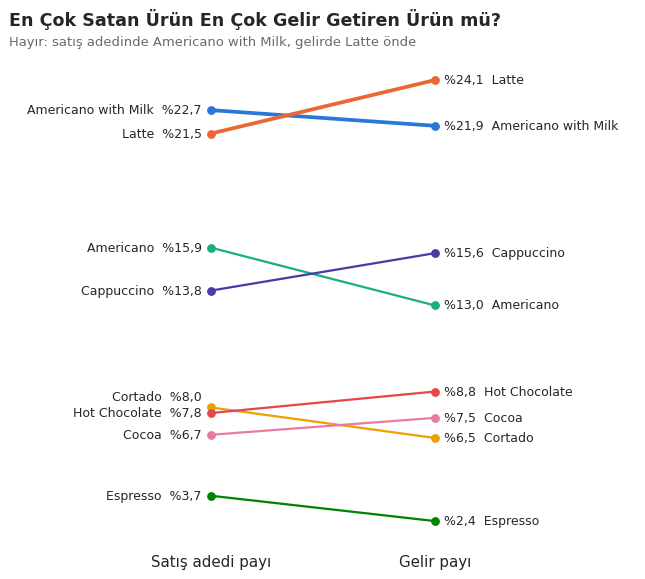

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))

for urun in urunler.index:
    sol = urunler.loc[urun, "satis_payi"]
    sag = urunler.loc[urun, "gelir_payi"]
    ana_urun = urun in ["Americano with Milk", "Latte"]   # hikâyenin iki ana ürünü kalın çizilsin
    ax.plot([0, 1], [sol, sag], color=renkler[urun], marker="o", lw=3 if ana_urun else 1.8)

    # Cortado ve Hot Chocolate etiketleri solda üst üste geliyor, Cortado'yu biraz yukarı aldım
    sol_etiket = sol + 0.5 if urun == "Cortado" else sol
    ax.text(-0.04, sol_etiket, f"{urun}  %{tr(sol)}", ha="right", va="center", fontsize=10)
    ax.text(1.04, sag, f"%{tr(sag)}  {urun}", ha="left", va="center", fontsize=10)

ax.set_xlim(-0.9, 1.9)
ax.set_xticks([0, 1], ["Satış adedi payı", "Gelir payı"], fontsize=12)
ax.set_yticks([])
ax.spines[["left", "bottom"]].set_visible(False)
baslik(ax, "En Çok Satan Ürün En Çok Gelir Getiren Ürün mü?",
       "Hayır: satış adedinde Americano with Milk, gelirde Latte önde")
kaydet(fig, "revenue_vs_sales")

**Bu bize ne söylüyor?**

Hayır, aynı ürün değil. Satış adedinde Americano with Milk önde, ama gelirde Latte ilk sırada: 27.866 ile toplam gelirin %24,1'i. Latte 42 adet daha az satılmasına rağmen yaklaşık 2.600 daha fazla gelir getiriyor. Sebebi fiyat farkı: Latte'nin ortalama fiyatı 35,6, Americano with Milk'inki 30,7.

Diğer ürünlerde de benzer bir durum var. Daha pahalı olan Cappuccino, Hot Chocolate ve Cocoa'nın gelir payı satış payından büyük. Daha ucuz olan Americano, Cortado ve Espresso'da ise tersi geçerli. Yani "en önemli ürün" hangisi sorusunun cevabı, neye baktığımıza göre değişiyor.

## 6. Kahve Satışları Hangi Saatte Yoğunlaşıyor?

Saatleri günlük hayattaki bölümlere de ayırdım: Sabah (06-09), Geç sabah (10-11), Öğle (12-13), İkindi (14-16), Akşam (17-22).

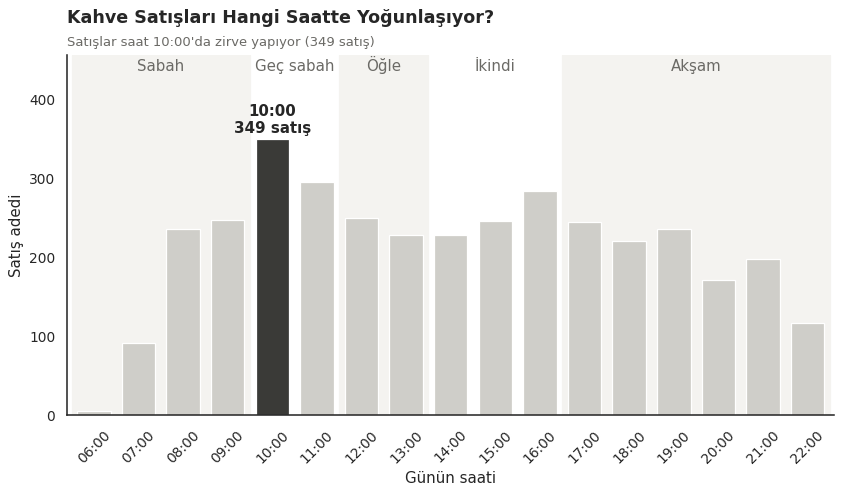

In [13]:
saatlik = df.groupby("hour").size()

fig, ax = plt.subplots(figsize=(11, 5.2))
renk = [KOYU if saat == 10 else ACIK for saat in saatlik.index]
ax.bar(saatlik.index, saatlik.values, color=renk, width=0.75)
ax.text(10, saatlik[10] + 8, f"10:00\n{saatlik[10]} satış", ha="center", fontweight="bold")

# Gün bölümlerini arka planda gösteriyorum
bolumler = [("Sabah", 6, 9), ("Geç sabah", 10, 11), ("Öğle", 12, 13), ("İkindi", 14, 16), ("Akşam", 17, 22)]
for i, (ad, bas, bit) in enumerate(bolumler):
    if i % 2 == 0:
        ax.axvspan(bas - 0.5, bit + 0.5, color="#f4f3f0", zorder=0)
    ax.text((bas + bit) / 2, 435, ad, ha="center", color=GRI_YAZI)

ax.set_ylim(0, 455)
ax.set_xlim(5.4, 22.6)
ax.set_xticks(saatlik.index, [f"{s:02d}:00" for s in saatlik.index], rotation=45)
ax.set_xlabel("Günün saati")
ax.set_ylabel("Satış adedi")
baslik(ax, "Kahve Satışları Hangi Saatte Yoğunlaşıyor?", "Satışlar saat 10:00'da zirve yapıyor (349 satış)")
kaydet(fig, "sales_by_hour")

Akşam dilimi 6 saat, geç sabah sadece 2 saat sürüyor. Bu yüzden toplamın yanında saat başına düşen satışa da baktım:

In [14]:
df["gun_bolumu"] = pd.cut(df["hour"], bins=[5, 9, 11, 13, 16, 22],
                          labels=["Sabah", "Geç sabah", "Öğle", "İkindi", "Akşam"])

bolum_tablo = df.groupby("gun_bolumu", observed=True).size().to_frame("satis")
bolum_tablo["saat_sayisi"] = [4, 2, 2, 3, 6]
bolum_tablo["pay_%"] = (bolum_tablo["satis"] / len(df) * 100).round(1)
bolum_tablo["saat_basina_satis"] = (bolum_tablo["satis"] / bolum_tablo["saat_sayisi"]).round(1)
bolum_tablo

,satis,saat_sayisi,pay_%,saat_basina_satis
gun_bolumu,,,,
Sabah,578,4,15.9,144.5
Geç sabah,643,2,17.7,321.5
Öğle,476,2,13.1,238.0
İkindi,756,3,20.8,252.0
Akşam,1183,6,32.5,197.2


**Bu bize ne söylüyor?**

En yoğun saat 10:00; bu saatte 349 satış yapılmış. 11:00 (294) ve 16:00 (283) onu takip ediyor.

İlk bakışta akşam en yoğun dilim gibi görünüyor (%32,5), ama bunun sebebi akşamın en uzun dilim olması. Saat başına bakınca açık ara en yoğun dilim geç sabah: saatte ortalama 321,5 satış, akşamda ise 197,2. Yani satışlar en çok 10:00-12:00 arasında yoğunlaşıyor.

## 7. Sabah ve Akşam Kahve Tercihleri Değişiyor mu?

Bu bölüm için günü üçe ayırdım: Sabah (06-11), Öğle (12-16), Akşam (17-22). Her dilimde hangi ürünün satışların ne kadarını oluşturduğuna baktım.

In [15]:
df["zaman"] = pd.cut(df["hour"], bins=[5, 11, 16, 22], labels=["Sabah", "Öğle", "Akşam"])

zaman_payi = pd.crosstab(df["coffee_name"], df["zaman"], normalize="columns") * 100
zaman_payi["fark"] = zaman_payi["Akşam"] - zaman_payi["Sabah"]
zaman_payi = zaman_payi.sort_values("fark")
zaman_payi.round(1)

zaman,Sabah,Öğle,Akşam,fark
coffee_name,,,,
Americano,18.4,19.4,9.6,-8.8
Cortado,11.9,7.4,4.7,-7.1
Americano with Milk,27.5,19.8,20.6,-6.9
Espresso,3.8,4.7,2.5,-1.2
Latte,19.2,22.1,23.3,4.2
Cocoa,4.8,6.2,9.0,4.2
Cappuccino,10.3,13.7,17.4,7.1
Hot Chocolate,4.1,6.7,12.7,8.6


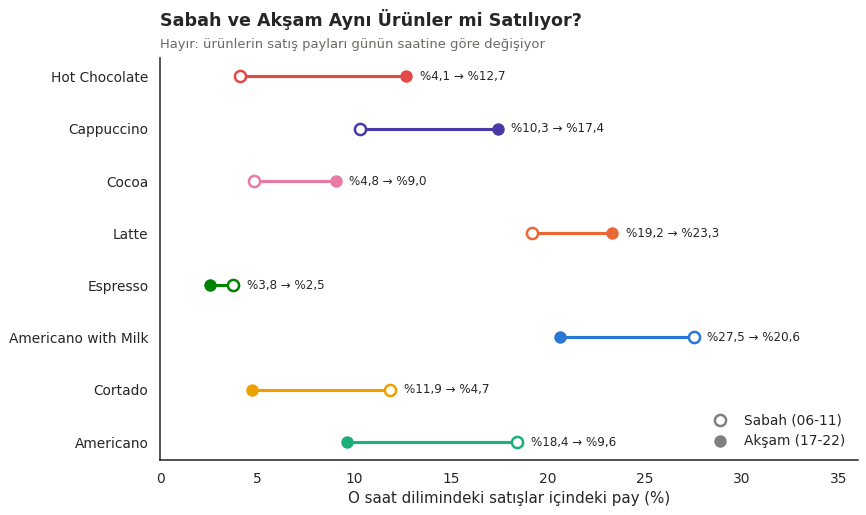

In [16]:
fig, ax = plt.subplots(figsize=(10, 5.8))

for i, urun in enumerate(zaman_payi.index):
    sabah = zaman_payi.loc[urun, "Sabah"]
    aksam = zaman_payi.loc[urun, "Akşam"]
    renk = renkler[urun]
    ax.plot([sabah, aksam], [i, i], color=renk, lw=2.5)
    ax.scatter(sabah, i, s=80, facecolor="white", edgecolor=renk, linewidth=2, zorder=3)  # boş nokta = sabah
    ax.scatter(aksam, i, s=80, color=renk, zorder=3)                                     # dolu nokta = akşam
    ax.text(max(sabah, aksam) + 0.7, i, f"%{tr(sabah)} → %{tr(aksam)}", va="center", fontsize=9.5)

ax.set_yticks(range(len(zaman_payi)), zaman_payi.index)
ax.set_xlim(0, 36)
ax.set_xlabel("O saat dilimindeki satışlar içindeki pay (%)")

# Açıklama kutusu için boş noktalar
ax.scatter([], [], s=80, facecolor="white", edgecolor="gray", linewidth=2, label="Sabah (06-11)")
ax.scatter([], [], s=80, color="gray", label="Akşam (17-22)")
ax.legend(frameon=False, loc="lower right")

baslik(ax, "Sabah ve Akşam Aynı Ürünler mi Satılıyor?",
       "Hayır: ürünlerin satış payları günün saatine göre değişiyor")
kaydet(fig, "morning_vs_evening")

**Bu bize ne söylüyor?**

Ürünlerin payı gün içinde belirgin şekilde değişiyor:
- Hot Chocolate'ın payı sabah %4,1 iken akşam %12,7'ye çıkıyor, yani üç katından fazla. Cappuccino (%10,3 → %17,4) ve Cocoa (%4,8 → %9,0) da akşam daha büyük pay alıyor.
- Americano (%18,4 → %9,6) ve Cortado (%11,9 → %4,7) ise sabah daha baskın. Americano with Milk de sabah satışlarının %27,5'ini oluştururken akşam %20,6'ya iniyor.
- Latte gün boyunca dengeli ve akşamın en çok satan ürünü (%23,3).

Burada dikkat ettiğim bir nokta var: veri müşterilerin neden böyle tercih yaptığını göstermiyor. Sadece hangi saatte hangi ürünün daha çok satıldığını gösteriyor.

## 8. Hafta İçi ve Hafta Sonu Farkı

Veride her günden aynı sayıda yok; örneğin 56 Cuma var ama 52 Çarşamba var. O yüzden toplam satışın yanında gün başına ortalama satışı da hesapladım.

In [17]:
gunluk = df.groupby("weekday").agg(toplam_satis=("money", "count"), gun_sayisi=("date", "nunique"))
gunluk["gunluk_ortalama"] = (gunluk["toplam_satis"] / gunluk["gun_sayisi"]).round(2)
gunluk = gunluk.loc[gunler]   # günleri Pazartesi'den Pazar'a sıralıyorum
gunluk

,toplam_satis,gun_sayisi,gunluk_ortalama
weekday,,,
Pazartesi,561,55,10.20
Salı,585,55,10.64
Çarşamba,510,52,9.81
Perşembe,520,54,9.63
Cuma,544,56,9.71
Cumartesi,482,55,8.76
Pazar,434,54,8.04


In [18]:
hafta = df.groupby("is_weekend").agg(toplam_satis=("money", "count"), gun_sayisi=("date", "nunique"))
hafta["gunluk_ortalama"] = hafta["toplam_satis"] / hafta["gun_sayisi"]

hafta_ici = hafta.loc[False, "gunluk_ortalama"]
hafta_sonu = hafta.loc[True, "gunluk_ortalama"]
fark = (hafta_ici - hafta_sonu) / hafta_ici * 100

print("Hafta içi günlük ortalama :", round(hafta_ici, 1))
print("Hafta sonu günlük ortalama:", round(hafta_sonu, 1))
print("Hafta sonu ne kadar düşük : %", round(fark, 1))

Hafta içi günlük ortalama : 10.0
Hafta sonu günlük ortalama: 8.4
Hafta sonu ne kadar düşük : % 16.0


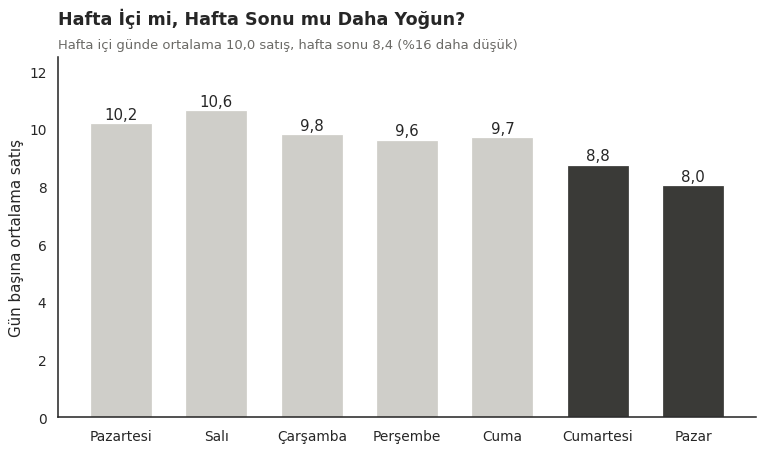

In [19]:
fig, ax = plt.subplots(figsize=(10, 5.2))
renk = [KOYU if gun in ["Cumartesi", "Pazar"] else ACIK for gun in gunluk.index]
ax.bar(gunluk.index, gunluk["gunluk_ortalama"], color=renk, width=0.65)

for i, deger in enumerate(gunluk["gunluk_ortalama"]):
    ax.text(i, deger + 0.15, tr(deger), ha="center")

ax.set_ylim(0, 12.5)
ax.set_ylabel("Gün başına ortalama satış")
baslik(ax, "Hafta İçi mi, Hafta Sonu mu Daha Yoğun?",
       f"Hafta içi günde ortalama {tr(hafta_ici)} satış, hafta sonu {tr(hafta_sonu)} (%{tr(fark, 0)} daha düşük)")
kaydet(fig, "sales_by_day")

**Bu bize ne söylüyor?**

Hafta sonu daha sakin. Hafta içi günde ortalama 10,0 satış yapılırken hafta sonu bu sayı 8,4'e düşüyor; yaklaşık %16 daha az. En yoğun gün Salı (günde 10,6 satış), en sakin gün Pazar (8,0). Toplam satışlarda da sıralama aynı: Salı 585 satışla ilk, Pazar 434 satışla son sırada.

## 9. Satışlar Yıl İçinde Nasıl Değişiyor?

Burada iki şeye dikkat ettim. Birincisi, aylar farklı sayıda gün içeriyor. İkincisi, Mart 2025 tam bir ay değil, veri 23 Mart'ta bitiyor. Bu yüzden aylık toplamın yanına günlük ortalamayı da ekledim.

In [20]:
aylik = df.groupby("year_month").agg(
    satis=("money", "count"),
    gelir=("money", "sum"),
    gun_sayisi=("date", "nunique"),
)
aylik["gunluk_ortalama"] = aylik["satis"] / aylik["gun_sayisi"]
aylik.round(1)

,satis,gelir,gun_sayisi,gunluk_ortalama
year_month,,,,
2024-03,206,7050.2,31,6.6
2024-04,196,6720.6,30,6.5
2024-05,267,9063.4,28,9.5
2024-06,227,7758.8,30,7.6
2024-07,237,6915.9,31,7.6
2024-08,272,7613.8,31,8.8
2024-09,344,9988.6,30,11.5
2024-10,426,13891.2,31,13.7
2024-11,259,8590.5,29,8.9


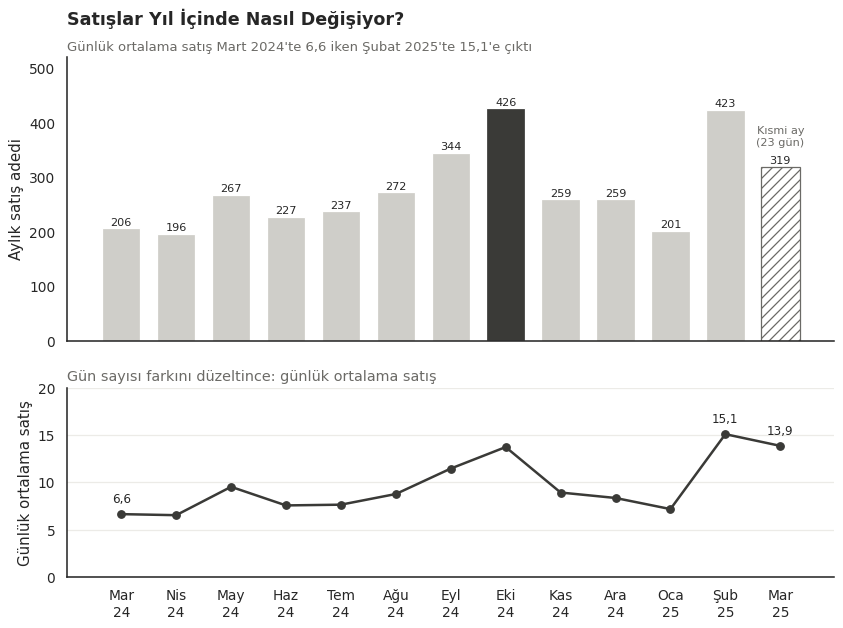

In [21]:
ay_adlari = ["Oca", "Şub", "Mar", "Nis", "May", "Haz", "Tem", "Ağu", "Eyl", "Eki", "Kas", "Ara"]
etiketler = [f"{ay_adlari[p.month - 1]}\n{str(p.year)[2:]}" for p in aylik.index]
x = np.arange(len(aylik))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True, gridspec_kw={"height_ratios": [3, 2]})

# Üst grafik: aylık toplam satış (en yüksek ay koyu, son ay kısmi olduğu için taralı)
renk = [KOYU if s == aylik["satis"].max() else ACIK for s in aylik["satis"]]
ax1.bar(x[:-1], aylik["satis"][:-1], color=renk[:-1], width=0.7)
ax1.bar(x[-1], aylik["satis"].iloc[-1], color="white", edgecolor=GRI_YAZI, hatch="///", width=0.7)
for i, s in enumerate(aylik["satis"]):
    ax1.text(i, s + 6, s, ha="center", fontsize=9)
ax1.text(x[-1], aylik["satis"].iloc[-1] + 40, "Kısmi ay\n(23 gün)", ha="center", fontsize=9, color=GRI_YAZI)
ax1.set_ylim(0, 520)
ax1.set_ylabel("Aylık satış adedi")
baslik(ax1, "Satışlar Yıl İçinde Nasıl Değişiyor?",
       "Günlük ortalama satış Mart 2024'te 6,6 iken Şubat 2025'te 15,1'e çıktı")

# Alt grafik: günlük ortalama satış
ax2.plot(x, aylik["gunluk_ortalama"], color=KOYU, marker="o", lw=2)
for i in [0, 11, 12]:   # Mart 2024, Şubat 2025, Mart 2025
    ax2.text(i, aylik["gunluk_ortalama"].iloc[i] + 1.2, tr(aylik["gunluk_ortalama"].iloc[i]), ha="center", fontsize=9.5)
ax2.set_ylim(0, 20)
ax2.set_ylabel("Günlük ortalama satış")
ax2.set_title("Gün sayısı farkını düzeltince: günlük ortalama satış", fontsize=11.5, color=GRI_YAZI, fontweight="normal")
ax2.grid(axis="y", color="#ecebe7")
ax2.set_xticks(x, etiketler)
kaydet(fig, "monthly_sales")

**Bu bize ne söylüyor?**

- Toplamda en çok satış yapılan ay Ekim 2024 (426), en az yapılan ay Nisan 2024 (196).
- Gün sayısını hesaba katınca tablo biraz değişiyor: günlük ortalamada zirve Şubat 2025 (günde 15,1 satış). Şubat 28 gün olduğu için toplamda Ekim'in hemen gerisinde kalıyor.
- Genel eğilim yukarı doğru. Mart-Nisan 2024'te günde yaklaşık 6,5 satış yapılırken Şubat-Mart 2025'te bu sayı 14-15'e çıkmış, yani iki katından fazla. Arada Eylül-Ekim 2024'te bir yükseliş, Kasım 2024 - Ocak 2025 arasında ise bir düşüş var.
- Mart 2025 kısmi ay olduğu için toplamda düşük görünüyor, ama günlük ortalamada (13,9) güçlü bir ay.

Veri bu iniş çıkışların nedenini (mevsim, fiyat vb.) söylemiyor.

## 10. Müşteriler Nasıl Ödeme Yapıyor?

In [22]:
odeme = df["cash_type"].value_counts().to_frame("islem")
odeme["pay_%"] = (odeme["islem"] / len(df) * 100).round(1)
odeme["ort_tutar"] = df.groupby("cash_type")["money"].mean().round(2)
print(odeme)

son_nakit = df[df["cash_type"] == "cash"]["date"].max()
print("\nSon nakit ödeme:", son_nakit.date())
print("Bu tarihten sonraki nakit ödeme sayısı:", ((df["cash_type"] == "cash") & (df["date"] > son_nakit)).sum())

# Nakitin kullanıldığı dönemde kart ve nakit ortalaması
ilk_donem = df[df["date"] <= son_nakit]
print("\nO dönemde ortalama tutar:")
print(ilk_donem.groupby("cash_type")["money"].mean().round(2))

           islem  pay_%  ort_tutar
cash_type                         
card        3547   97.6      31.65
cash          89    2.4      35.80

Son nakit ödeme: 2024-06-03
Bu tarihten sonraki nakit ödeme sayısı: 0

O dönemde ortalama tutar:
cash_type
card    33.94
cash    35.80
Name: money, dtype: float64


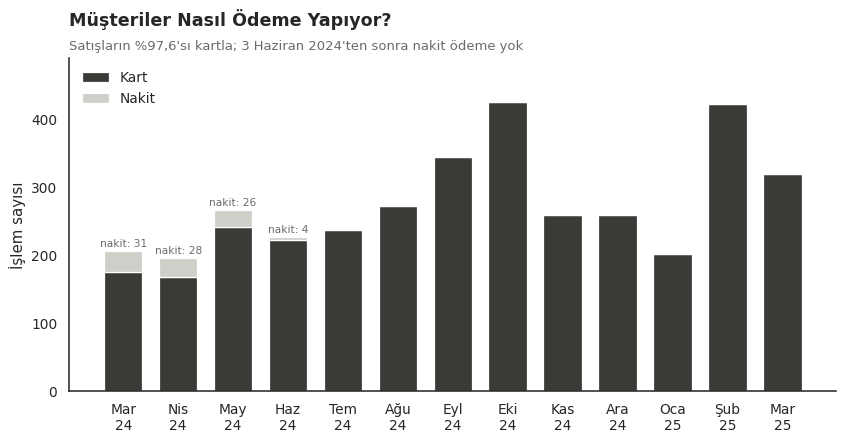

In [23]:
aylik_odeme = df.groupby(["year_month", "cash_type"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(x, aylik_odeme["card"], color=KOYU, width=0.7, label="Kart")
ax.bar(x, aylik_odeme["cash"], bottom=aylik_odeme["card"], color=ACIK, width=0.7, label="Nakit")

for i, nakit in enumerate(aylik_odeme["cash"]):
    if nakit > 0:
        ax.text(i, aylik_odeme.iloc[i].sum() + 6, f"nakit: {nakit}", ha="center", fontsize=8.5, color=GRI_YAZI)

ax.set_xticks(x, etiketler)
ax.set_ylim(0, 490)
ax.set_ylabel("İşlem sayısı")
ax.legend(frameon=False, loc="upper left")
baslik(ax, "Müşteriler Nasıl Ödeme Yapıyor?", "Satışların %97,6'sı kartla; 3 Haziran 2024'ten sonra nakit ödeme yok")
kaydet(fig, "payment_methods")

**Bu bize ne söylüyor?**

Satışların %97,6'sı kartla yapılmış, nakit sadece 89 işlemde (%2,4) var. Başka bir ödeme yöntemi yok.

Zaman içinde de bir değişim var: nakit ödemelerin hepsi Mart-Haziran 2024 arasında ve 3 Haziran 2024'ten sonra hiç nakit işlem yok. Veri bunun nedenini söylemiyor.

İlk bakışta nakit ödemeler daha yüksek tutarlı görünüyor (35,8'e karşılık 31,6). Ama nakitin kullanıldığı döneme bakınca fark çok küçülüyor (35,8'e karşılık 33,9). Yani bu fark büyük ölçüde ödeme yönteminden değil, o dönemdeki daha yüksek fiyatlardan kaynaklanıyor.

## 11. Öne Çıkan Bulgular

- **En popüler ürün:** Americano with Milk, 824 satış (%22,7). Yaklaşık her 4-5 satıştan biri.
- **En çok satan ≠ en çok kazandıran:** Satış adedinde Americano with Milk, gelirde Latte önde (%24,1).
- **En yoğun saat:** 10:00, 349 satış. Saat başına en yoğun dilim geç sabah.
- **Gün içinde tercihler değişiyor:** Hot Chocolate'ın payı sabah %4,1, akşam %12,7. Americano'da tersi: %18,4'ten %9,6'ya.
- **Hafta sonu daha sakin:** Hafta sonu günlük satışlar hafta içinden yaklaşık %16 düşük. En yoğun gün Salı, en sakin gün Pazar.
- **Satışlar yıl içinde arttı:** Günlük ortalama satış Mart 2024'te 6,6, Şubat 2025'te 15,1.
- **Kart kullanımı çok yüksek:** Satışların %97,6'sı kartla. 3 Haziran 2024'ten sonra hiç nakit ödeme yok.

## 12. İş Açısından Ne Anlama Geliyor?

Bunlar veride gördüğüm desenlerden çıkardığım fikirler. Nedensellik göstermiyorlar; denenip ölçülmesi gereken öneriler olarak düşündüm.

- **Stok:** Satışlar 10:00'da zirve yaptığı için stok kontrolü ve dolum bu saatten önce yapılabilir.
- **Ürün planlaması:** Sabah kahve, akşam çikolatalı içeceklerin payı artıyor. Malzemeler buna göre planlanabilir.
- **Bakım / hazırlık:** Bakım ve temizlik gibi işler yoğun saatlerden önce, sabah erken yapılabilir.
- **Gelir takibi:** Latte ve Cappuccino gelir, Americano with Milk ise satış adedi açısından kilit ürünler.
- **Hafta sonu:** Hafta sonu satışları daha düşük olduğu için küçük kampanyalar denenebilir.
- **Ödeme:** Satışların neredeyse tamamı kartla yapıldığı için kart okuyucunun kesintisiz çalışması önemli.

## 13. Veri Setinin Sınırlılıkları

- Veri bir kahve otomatına ait. Konum, maliyet ve kâr bilgisi yok; bu yüzden sonuçlar kârlılık hakkında değil, satışlar hakkında.
- Müşteri bilgisi (yaş, tercih nedeni vb.) yok. Kart numaraları anonim ve bir kart her zaman tek bir kişi anlamına gelmiyor.
- Para birimi belirtilmemiş, fiyatlar dönem içinde değişmiş.
- Mart 2025 kısmi bir ay (23 gün) ve 388 günün 7'sinde hiç satış kaydı yok.

## 14. Sonuç

Bu analizde 3.636 kahve satışına basit sorularla baktım. Beni en çok düşündüren sonuç, çok satmak ile çok kazanmanın aynı şey olmaması oldu: Americano with Milk en çok satan ürün, ama Latte daha yüksek fiyatı sayesinde en fazla geliri getiriyor. Satışlar sabah 10:00 civarında zirve yapıyor, hafta içi hafta sonundan daha yoğun geçiyor. Gün ilerledikçe de sade kahvelerden çikolatalı içeceklere doğru bir kayma görülüyor.

Bu bulgular stok, bakım ve ödeme altyapısı gibi konularda fikir veriyor. Ancak veride müşterilerin neden böyle davrandığına dair bilgi olmadığı için bunları kesin sonuçlar değil, test edilebilecek fikirler olarak görüyorum.